<a href="https://colab.research.google.com/github/mperumal-usd/capstone_team_3/blob/main/notebooks/COLAB_MERT_Finetune_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MERT Fine-Tuning with LoRA: Composer Similarity (v3)

Fine-tunes `m-a-p/MERT-v1-95M` using LoRA adapters on all attention projections.
No projection head — the 768-dim L2-normalized MERT output is used directly with TripletMarginLoss.

## Sections
- **Section 0** — Setup (install deps, mount Drive, config)
- **Section 1** — Triplet CSV generation (always regenerated)
- **Section 2** — Train/val split (skips if Drive files exist)
- **Section 3** — LoRA training (intra-epoch checkpointing every N steps)
- **Section 4** — Evaluation

**Resume after disconnect:** Run all cells top-to-bottom. Each section checks Drive for its checkpoint and skips if already done. Training resumes from the last saved step.

In [ ]:
# ── Section 0: Setup ──────────────────────────────────────────────────────────
!pip install -q transformers peft accelerate librosa numpy pandas scikit-learn tqdm

from google.colab import drive
drive.mount('/content/drive')

import os, json, random, re
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import librosa
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoProcessor
from peft import LoraConfig, get_peft_model, PeftModel
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt

# ── Config ────────────────────────────────────────────────────────────────────
DRIVE_BASE   = "/content/drive/MyDrive/AAI-590 Capstone/checkpoints3"
CHUNK_PATH   = "/content/drive/MyDrive/AAI-590 Capstone/AAI590_FinalProject/ChunkSamples"
MODEL_NAME   = "m-a-p/MERT-v1-95M"
SR           = 24000
LORA_R       = 8
LORA_ALPHA   = 16
LORA_DROPOUT = 0.05
LORA_TARGETS = ["q_proj", "k_proj", "v_proj", "o_proj"]
MARGIN       = 0.3
BATCH_SIZE   = 8        # each triplet = 3 WAV forward passes through MERT
LR           = 5e-5
EPOCHS       = 10
SAVE_STEPS   = 200      # save checkpoint every N optimizer steps
SEED         = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# Create Drive subdirectories
for sub in ["splits", "checkpoints/lora_best", "checkpoints/lora_last", "results"]:
    os.makedirs(os.path.join(DRIVE_BASE, sub), exist_ok=True)
print("Drive folders ready.")

Mounted at /content/drive
Device: cuda
Drive folders ready.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
CHUNK_PATH   = "/content/drive/MyDrive/AAI-590 Capstone/AAI590_FinalProject/ChunkSamples"
TRIPLET_CSV = os.path.join(DRIVE_BASE, "triplet_df.csv")

## Section 1 — Triplet CSV Generation
Regenerates (anchor, positive, negative) DataFrame from ChunkSamples and saves to Drive.
Always re-runs (~30 seconds). Anchor = first chunk of each song; positives = remaining chunks;
negative = chunks from a randomly chosen different composer.

In [ ]:
# ── Section 1: Triplet CSV ────────────────────────────────────────────────────
TRIPLET_CSV = os.path.join(DRIVE_BASE, "triplet_df.csv")

def numeric_sort(f):
    match = re.search(r'_chunk_(\d+)\.wav$', f)
    return int(match.group(1)) if match else -1

data = []
used_negatives = set()

for composer in os.listdir(CHUNK_PATH):
    composer_path = os.path.join(CHUNK_PATH, composer)
    if not os.path.isdir(composer_path):
        continue
    for song in os.listdir(composer_path):
        song_path = os.path.join(composer_path, song)
        if not os.path.isdir(song_path):
            continue
        chunks = sorted(
            [f for f in os.listdir(song_path) if f.endswith(".wav")],
            key=numeric_sort
        )
        if len(chunks) < 2:
            continue
        anchor    = chunks[0]
        positives = chunks[1:]
        other_composers = [
            c for c in os.listdir(CHUNK_PATH)
            if c != composer and os.path.isdir(os.path.join(CHUNK_PATH, c))
        ]
        if not other_composers:
            continue
        chosen_composer      = random.choice(other_composers)
        chosen_composer_path = os.path.join(CHUNK_PATH, chosen_composer)
        negative_pool = []
        for other_song in sorted(os.listdir(chosen_composer_path)):
            other_song_path = os.path.join(chosen_composer_path, other_song)
            if not os.path.isdir(other_song_path):
                continue
            for f in sorted(os.listdir(other_song_path), key=numeric_sort):
                if f.endswith(".wav") and f not in used_negatives:
                    negative_pool.append(f)
        min_len = min(len(positives), len(negative_pool))
        for i in range(min_len):
            data.append({
                "anchor":   anchor,
                "positive": positives[i],
                "negative": negative_pool[i],
                "composer": composer,
                "song":     song,
            })
            used_negatives.add(negative_pool[i])

df = pd.DataFrame(data)
df.to_csv(TRIPLET_CSV, index=False)
print(f"Triplet CSV saved → {TRIPLET_CSV}")
print(f"Total triplets: {len(df)}")
print(df.head())

In [ ]:
df = pd.read_csv(TRIPLET_CSV)
print(f"Triplet CSV saved → {TRIPLET_CSV}")
print(f"Total triplets: {len(df)}")
print(df.head())

Triplet CSV saved → /content/drive/MyDrive/AAI-590 Capstone/checkpoints3/triplet_df.csv
Total triplets: 23183
                 anchor              positive             negative composer  \
0  bach_847_chunk_1.wav  bach_847_chunk_2.wav  islamei_chunk_1.wav     bach   
1  bach_847_chunk_1.wav  bach_847_chunk_3.wav  islamei_chunk_2.wav     bach   
2  bach_847_chunk_1.wav  bach_847_chunk_4.wav  islamei_chunk_3.wav     bach   
3  bach_847_chunk_1.wav  bach_847_chunk_5.wav  islamei_chunk_4.wav     bach   
4  bach_847_chunk_1.wav  bach_847_chunk_6.wav  islamei_chunk_5.wav     bach   

       song  
0  bach_847  
1  bach_847  
2  bach_847  
3  bach_847  
4  bach_847  


## Section 2 — Train/Val Split
80/20 stratified split on composer. Skips if Drive files already exist.

In [ ]:
# ── Section 2: Train/val split ────────────────────────────────────────────────
TRAIN_IDX_PATH = os.path.join(DRIVE_BASE, "splits", "train_idx.npy")
VAL_IDX_PATH   = os.path.join(DRIVE_BASE, "splits",   "val_idx.npy")

if os.path.exists(TRAIN_IDX_PATH) and os.path.exists(VAL_IDX_PATH):
    train_idx = np.load(TRAIN_IDX_PATH)
    val_idx   = np.load(VAL_IDX_PATH)
    print(f"Loaded split from Drive. Train: {len(train_idx)}  Val: {len(val_idx)}")
else:
    all_idx = np.arange(len(df))
    train_idx, val_idx = train_test_split(
        all_idx,
        test_size=0.2,
        random_state=SEED,
        stratify=df["composer"].values
    )
    np.save(TRAIN_IDX_PATH, train_idx)
    np.save(VAL_IDX_PATH,   val_idx)
    print(f"Split saved to Drive. Train: {len(train_idx)}  Val: {len(val_idx)}")

train_df = df.iloc[train_idx].reset_index(drop=True)
val_df   = df.iloc[val_idx].reset_index(drop=True)
print(f"train_df: {len(train_df)} rows  val_df: {len(val_df)} rows")

Loaded split from Drive. Train: 18546  Val: 4637
train_df: 18546 rows  val_df: 4637 rows


## Section 3 — LoRA Training

### Architecture
```
MERT-v1-95M
  + LoRA adapters on q_proj, k_proj, v_proj, o_proj (all transformer layers)
  → mean-pool last_hidden_state → 768-dim
  → L2-normalize → 768-dim unit-sphere embedding
Loss: TripletMarginLoss(margin=0.3)
```

### Resume behaviour
Training state is saved every `SAVE_STEPS` optimizer steps to Drive (`training_state.json`).
On resume, the LoRA adapter and optimizer are reloaded and the loop skips already-completed batches.

In [ ]:
# ── Section 3A: Dataset + Model setup ────────────────────────────────────────

# Build filename → full path lookup
file_lookup = {}
for composer in os.listdir(CHUNK_PATH):
    cp = os.path.join(CHUNK_PATH, composer)
    if not os.path.isdir(cp):
        continue
    for song in os.listdir(cp):
        sp = os.path.join(cp, song)
        if not os.path.isdir(sp):
            continue
        for f in os.listdir(sp):
            if f.endswith(".wav"):
                file_lookup[f] = os.path.join(sp, f)
print(f"File lookup built: {len(file_lookup)} files")


class TripletWAVDataset(Dataset):
    """Loads WAV triplets on-the-fly from filenames."""
    def __init__(self, dataframe, file_lookup, processor, sr=24000):
        self.df          = dataframe.reset_index(drop=True)
        self.file_lookup = file_lookup
        self.processor   = processor
        self.sr          = sr

    def __len__(self):
        return len(self.df)

    def _load(self, fname):
        path  = self.file_lookup.get(fname)
        audio, _ = librosa.load(path, sr=self.sr)
        inputs   = self.processor(audio, sampling_rate=self.sr, return_tensors="pt")
        # squeeze batch dim added by processor
        return {k: v.squeeze(0) for k, v in inputs.items()}

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return (
            self._load(row["anchor"]),
            self._load(row["positive"]),
            self._load(row["negative"]),
        )


def collate_triplets(batch):
    """Stack variable-length inputs by padding to the longest in the batch."""
    anchors, positives, negatives = zip(*batch)

    def stack(items):
        # items is a list of dicts; pad input_values to same length
        max_len = max(x["input_values"].shape[-1] for x in items)
        padded  = []
        for x in items:
            iv = x["input_values"]  # (seq_len,)
            pad_len = max_len - iv.shape[-1]
            padded.append(F.pad(iv, (0, pad_len)))
        return {"input_values": torch.stack(padded)}

    return stack(anchors), stack(positives), stack(negatives)


# Load processor
processor = AutoProcessor.from_pretrained(MODEL_NAME, trust_remote_code=True)

# Load base MERT model
base_model = AutoModel.from_pretrained(MODEL_NAME, trust_remote_code=True)

# Apply LoRA
lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGETS,
    lora_dropout=LORA_DROPOUT,
    bias="none",
)
model = get_peft_model(base_model, lora_config)
model.to(DEVICE)
model.print_trainable_parameters()

# DataLoaders
train_dataset = TripletWAVDataset(train_df, file_lookup, processor, SR)
val_dataset   = TripletWAVDataset(val_df,   file_lookup, processor, SR)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=collate_triplets, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate_triplets, num_workers=2, pin_memory=True
)

criterion = torch.nn.TripletMarginLoss(margin=MARGIN, p=2)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
total_steps = EPOCHS * len(train_loader)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps)

print(f"Train batches: {len(train_loader)}  Val batches: {len(val_loader)}")
print(f"Total training steps: {total_steps}")

File lookup built: 43663 files


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'TypeError: Failed to fetch'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/211 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

configuration_MERT.py: 0.00B [00:00, ?B/s]

...

modeling_MERT.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/m-a-p/MERT-v1-95M:
- modeling_MERT.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

trainable params: 442,368 || all params: 94,814,080 || trainable%: 0.4666
Train batches: 2319  Val batches: 580
Total training steps: 23190


In [ ]:
# ── Section 3B: Training loop ─────────────────────────────────────────────────
LORA_BEST_DIR  = os.path.join(DRIVE_BASE, "checkpoints", "lora_best")
LORA_LAST_DIR  = os.path.join(DRIVE_BASE, "checkpoints", "lora_last")
OPT_STATE_PATH = os.path.join(DRIVE_BASE, "checkpoints", "optimizer_state.pt")
TRAIN_STATE    = os.path.join(DRIVE_BASE, "checkpoints", "training_state.json")
LOG_PATH       = os.path.join(DRIVE_BASE, "training_log.csv")


def get_embedding(model, batch_inputs):
    """Forward pass through LoRA-adapted MERT; return L2-normalised 768-dim embedding."""
    inputs = {k: v.to(DEVICE) for k, v in batch_inputs.items()}
    outputs = model(**inputs)
    emb = outputs.last_hidden_state.mean(dim=1)  # (batch, 768)
    return F.normalize(emb, p=2, dim=1)


In [ ]:


# ── Resume ────────────────────────────────────────────────────────────────────
start_epoch   = 0
resume_step   = 0       # steps already completed inside start_epoch
global_step   = 0
best_val_loss = float("inf")
training_log  = []

if os.path.exists(TRAIN_STATE):
    with open(TRAIN_STATE) as f:
        state = json.load(f)
    start_epoch   = state["epoch"]
    resume_step   = state["step"]       # batches done in start_epoch
    global_step   = state["global_step"]
    best_val_loss = state["best_val_loss"]
    # Load a fresh base model so PeftModel.from_pretrained has no stale
    # peft_config attached — avoids the "Already found peft_config" warning
    # and guarantees the new optimizer points at the correct parameters.
    opt_ckpt = torch.load(OPT_STATE_PATH, map_location=DEVICE)
    fresh_base = AutoModel.from_pretrained(MODEL_NAME, trust_remote_code=True)
    model = PeftModel.from_pretrained(fresh_base, LORA_LAST_DIR)
    model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
    optimizer.load_state_dict(opt_ckpt["optimizer"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps)
    scheduler.load_state_dict(opt_ckpt["scheduler"])
    print(f"Resumed: epoch={start_epoch} step={resume_step} global_step={global_step}")
else:
    print("No checkpoint found. Training from scratch.")

if os.path.exists(LOG_PATH):
    training_log = pd.read_csv(LOG_PATH).to_dict(orient="records")


def save_checkpoint(is_best=False, end_of_epoch=False):
    """Save LoRA adapter + optimizer state + training state to Drive.
    end_of_epoch=True advances the saved epoch/step so resume starts the
    NEXT epoch from batch 0 (avoids the all-batches-skipped bug).
    """
    model.save_pretrained(LORA_LAST_DIR)
    torch.save({"optimizer": optimizer.state_dict(),
                "scheduler": scheduler.state_dict()}, OPT_STATE_PATH)
    with open(TRAIN_STATE, "w") as f:
        json.dump({
            "epoch":         epoch + 1 if end_of_epoch else epoch,
            "step":          0         if end_of_epoch else batch_idx + 1,
            "global_step":   global_step,
            "best_val_loss": best_val_loss,
        }, f)
    if is_best:
        model.save_pretrained(LORA_BEST_DIR)


# ── Training ──────────────────────────────────────────────────────────────────
for epoch in range(start_epoch, EPOCHS):
    model.train()
    train_loss_total = 0.0
    train_batches    = 0

    for batch_idx, (a_in, p_in, n_in) in enumerate(
        tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [train]")
    ):
        # Skip already-completed batches on resume
        if epoch == start_epoch and batch_idx < resume_step:
            scheduler.step()
            global_step += 1
            continue

        a_emb = get_embedding(model, a_in)
        p_emb = get_embedding(model, p_in)
        n_emb = get_embedding(model, n_in)

        loss = criterion(a_emb, p_emb, n_emb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        train_loss_total += loss.item()
        train_batches    += 1
        global_step      += 1

        # Intra-epoch checkpoint
        if global_step % SAVE_STEPS == 0:
            save_checkpoint(is_best=False)

    avg_train_loss = train_loss_total / max(train_batches, 1)

    # ── Validation ────────────────────────────────────────────────────────────
    model.eval()
    val_loss_total = 0.0
    val_pos_sim    = 0.0
    val_neg_sim    = 0.0

    with torch.no_grad():
        for a_in, p_in, n_in in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [val]"):
            a_emb = get_embedding(model, a_in)
            p_emb = get_embedding(model, p_in)
            n_emb = get_embedding(model, n_in)
            loss  = criterion(a_emb, p_emb, n_emb)
            val_loss_total += loss.item()
            val_pos_sim += F.cosine_similarity(a_emb, p_emb).mean().item()
            val_neg_sim += F.cosine_similarity(a_emb, n_emb).mean().item()

    avg_val_loss = val_loss_total / len(val_loader)
    avg_pos_sim  = val_pos_sim   / len(val_loader)
    avg_neg_sim  = val_neg_sim   / len(val_loader)

    # ── Log ───────────────────────────────────────────────────────────────────
    is_best = avg_val_loss < best_val_loss
    if is_best:
        best_val_loss = avg_val_loss

    row = {
        "epoch":       epoch + 1,
        "global_step": global_step,
        "train_loss":  round(avg_train_loss, 6),
        "val_loss":    round(avg_val_loss,   6),
        "val_pos_sim": round(avg_pos_sim,    4),
        "val_neg_sim": round(avg_neg_sim,    4),
        "val_gap":     round(avg_pos_sim - avg_neg_sim, 4),
        "lr":          optimizer.param_groups[0]["lr"],
        "best":        is_best,
    }
    training_log.append(row)
    pd.DataFrame(training_log).to_csv(LOG_PATH, index=False)

    # Save end-of-epoch checkpoint (and best if improved)
    save_checkpoint(is_best=is_best, end_of_epoch=True)
    resume_step = 0   # next epoch starts from batch 0

    print(
        f"Epoch {epoch+1:02d} | "
        f"train_loss={avg_train_loss:.4f} val_loss={avg_val_loss:.4f} "
        f"pos_sim={avg_pos_sim:.4f} neg_sim={avg_neg_sim:.4f} "
        f"gap={avg_pos_sim - avg_neg_sim:.4f}"
        + ("  ✓ best" if is_best else "")
    )

print(f"\nTraining complete. Best val_loss={best_val_loss:.4f}")
print(f"Best LoRA adapter → {LORA_BEST_DIR}")

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Resumed: epoch=1 step=1081 global_step=3800


Epoch 2/10 [val]: 100%|██████████| 580/580 [07:52<00:00,  1.23it/s]


Epoch 02 | train_loss=0.2387 val_loss=0.2337 pos_sim=0.8362 neg_sim=0.7752 gap=0.0609


Epoch 3/10 [train]:  17%|█▋        | 393/2319 [01:58<09:39,  3.32it/s]


KeyboardInterrupt: 

## Section 4 — Evaluation
Loads the best LoRA adapter and computes cosine similarity distributions on the val set.
Saves results and a 2-panel histogram to Drive.

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Best LoRA adapter loaded from /content/drive/MyDrive/AAI-590 Capstone/checkpoints3/checkpoints/lora_best


Evaluating: 100%|██████████| 580/580 [01:16<00:00,  7.59it/s]


finetune_pos_mean  0.8362
finetune_neg_mean  0.7752
finetune_gap       0.0609
finetune_pos_std   0.1133
finetune_neg_std   0.1422


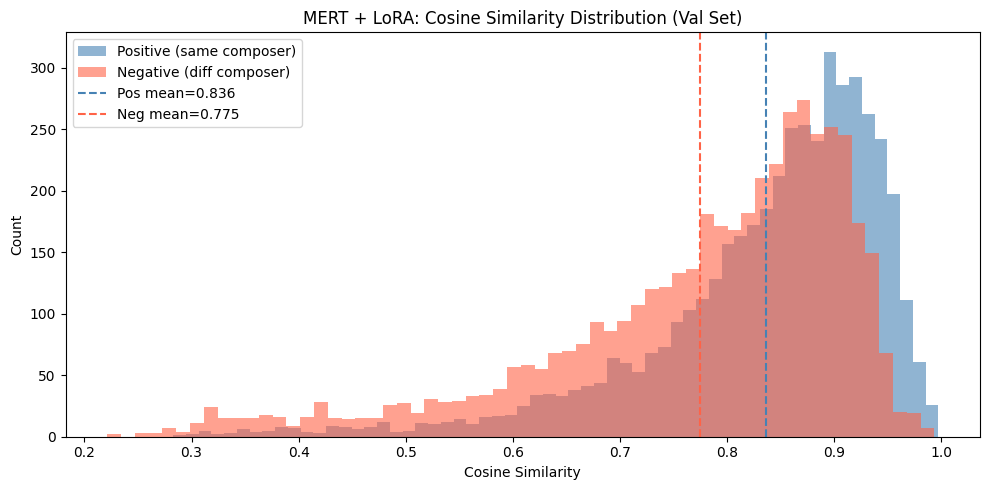

Plot saved → /content/drive/MyDrive/AAI-590 Capstone/checkpoints3/results/score_plot.png
Eval results saved → /content/drive/MyDrive/AAI-590 Capstone/checkpoints3/results/eval_results.csv


In [ ]:
# ── Section 4: Evaluation ─────────────────────────────────────────────────────
EVAL_CSV  = os.path.join(DRIVE_BASE, "results", "eval_results.csv")
PLOT_PATH = os.path.join(DRIVE_BASE, "results", "score_plot.png")

# Load best LoRA adapter
eval_model = PeftModel.from_pretrained(
    AutoModel.from_pretrained(MODEL_NAME, trust_remote_code=True),
    LORA_BEST_DIR
)
eval_model.to(DEVICE)
eval_model.eval()
print(f"Best LoRA adapter loaded from {LORA_BEST_DIR}")

# ── Compute fine-tuned cosine similarities on val set ─────────────────────────
ft_pos_sims, ft_neg_sims = [], []

with torch.no_grad():
    for a_in, p_in, n_in in tqdm(val_loader, desc="Evaluating"):
        a_emb = get_embedding(eval_model, a_in)
        p_emb = get_embedding(eval_model, p_in)
        n_emb = get_embedding(eval_model, n_in)
        ft_pos_sims.append(F.cosine_similarity(a_emb, p_emb).cpu().numpy())
        ft_neg_sims.append(F.cosine_similarity(a_emb, n_emb).cpu().numpy())

ft_pos_sim = np.concatenate(ft_pos_sims)
ft_neg_sim = np.concatenate(ft_neg_sims)

# ── Summary table ─────────────────────────────────────────────────────────────
results = {
    "finetune_pos_mean": round(float(ft_pos_sim.mean()), 4),
    "finetune_neg_mean": round(float(ft_neg_sim.mean()), 4),
    "finetune_gap":      round(float(ft_pos_sim.mean() - ft_neg_sim.mean()), 4),
    "finetune_pos_std":  round(float(ft_pos_sim.std()),  4),
    "finetune_neg_std":  round(float(ft_neg_sim.std()),  4),
}
results_df = pd.DataFrame([results])
results_df.to_csv(EVAL_CSV, index=False)
print(results_df.T.to_string(header=False))

# ── Distribution plot ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ft_pos_sim, bins=60, alpha=0.6, label="Positive (same composer)", color="steelblue")
ax.hist(ft_neg_sim, bins=60, alpha=0.6, label="Negative (diff composer)", color="tomato")
ax.axvline(ft_pos_sim.mean(), color="steelblue", linestyle="--", linewidth=1.5,
           label=f"Pos mean={ft_pos_sim.mean():.3f}")
ax.axvline(ft_neg_sim.mean(), color="tomato",    linestyle="--", linewidth=1.5,
           label=f"Neg mean={ft_neg_sim.mean():.3f}")
ax.set_title("MERT + LoRA: Cosine Similarity Distribution (Val Set)")
ax.set_xlabel("Cosine Similarity")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_PATH, dpi=150)
plt.show()
print(f"Plot saved → {PLOT_PATH}")
print(f"Eval results saved → {EVAL_CSV}")

In [ ]:
# ── Section 4: Evaluation ─────────────────────────────────────────────────────
DRIVE_BASE   = "/content/drive/MyDrive/AAI-590 Capstone/MERT_Finetune"
EVAL_CSV  = os.path.join(DRIVE_BASE, "results", "eval_results.csv")
PLOT_PATH = os.path.join(DRIVE_BASE, "results", "score_plot.png")
LORA_BEST_DIR= os.path.join(DRIVE_BASE, "checkpoints", "lora_best")
# Load best LoRA adapter
eval_model = PeftModel.from_pretrained(
    AutoModel.from_pretrained(MODEL_NAME, trust_remote_code=True),
    LORA_BEST_DIR
)
eval_model.to(DEVICE)
eval_model.eval()
print(f"Best LoRA adapter loaded from {LORA_BEST_DIR}")

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Best LoRA adapter loaded from /content/drive/MyDrive/AAI-590 Capstone/MERT_Finetune/checkpoints/lora_best


Evaluating: 100%|██████████| 580/580 [01:15<00:00,  7.66it/s]


finetune_pos_mean  0.6848
finetune_neg_mean  0.4394
finetune_gap       0.2455
finetune_pos_std   0.2140
finetune_neg_std   0.2242


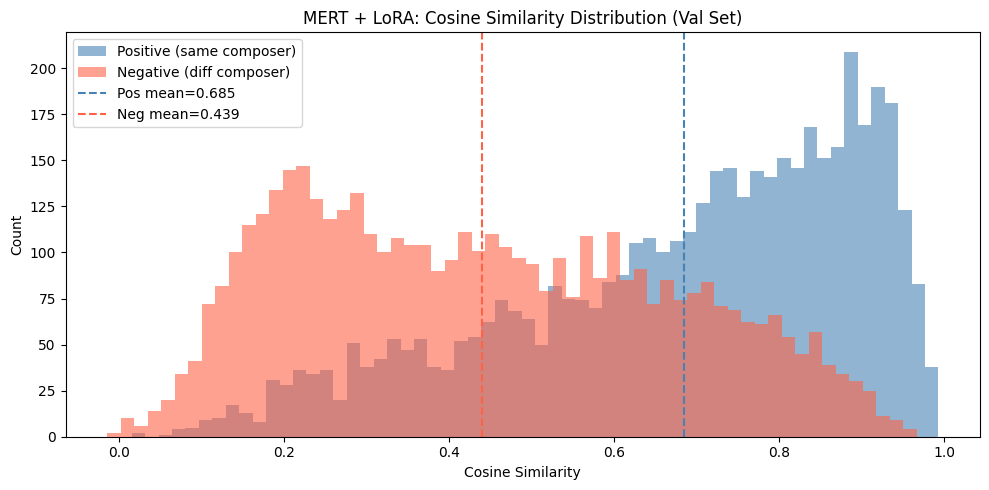

Plot saved → /content/drive/MyDrive/AAI-590 Capstone/MERT_Finetune/results/score_plot.png
Eval results saved → /content/drive/MyDrive/AAI-590 Capstone/MERT_Finetune/results/eval_results.csv


In [ ]:
# ── Compute fine-tuned cosine similarities on val set ─────────────────────────
ft_pos_sims, ft_neg_sims = [], []

with torch.no_grad():
    for a_in, p_in, n_in in tqdm(val_loader, desc="Evaluating"):
        a_emb = get_embedding(eval_model, a_in)
        p_emb = get_embedding(eval_model, p_in)
        n_emb = get_embedding(eval_model, n_in)
        ft_pos_sims.append(F.cosine_similarity(a_emb, p_emb).cpu().numpy())
        ft_neg_sims.append(F.cosine_similarity(a_emb, n_emb).cpu().numpy())

ft_pos_sim = np.concatenate(ft_pos_sims)
ft_neg_sim = np.concatenate(ft_neg_sims)

# ── Summary table ─────────────────────────────────────────────────────────────
results = {
    "finetune_pos_mean": round(float(ft_pos_sim.mean()), 4),
    "finetune_neg_mean": round(float(ft_neg_sim.mean()), 4),
    "finetune_gap":      round(float(ft_pos_sim.mean() - ft_neg_sim.mean()), 4),
    "finetune_pos_std":  round(float(ft_pos_sim.std()),  4),
    "finetune_neg_std":  round(float(ft_neg_sim.std()),  4),
}
results_df = pd.DataFrame([results])
results_df.to_csv(EVAL_CSV, index=False)
print(results_df.T.to_string(header=False))

# ── Distribution plot ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ft_pos_sim, bins=60, alpha=0.6, label="Positive (same composer)", color="steelblue")
ax.hist(ft_neg_sim, bins=60, alpha=0.6, label="Negative (diff composer)", color="tomato")
ax.axvline(ft_pos_sim.mean(), color="steelblue", linestyle="--", linewidth=1.5,
           label=f"Pos mean={ft_pos_sim.mean():.3f}")
ax.axvline(ft_neg_sim.mean(), color="tomato",    linestyle="--", linewidth=1.5,
           label=f"Neg mean={ft_neg_sim.mean():.3f}")
ax.set_title("MERT + LoRA: Cosine Similarity Distribution (Val Set)")
ax.set_xlabel("Cosine Similarity")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_PATH, dpi=150)
plt.show()
print(f"Plot saved → {PLOT_PATH}")
print(f"Eval results saved → {EVAL_CSV}")

Generate embeddings for all .wav chunks in a DF in gog. it should have filename, chunk index, then 768 embeddings. store it as a pickle format. IT is used for FAAIS search later

## Generate Embeddings for FAISS Search
Extracts 768-dim embeddings for all `.wav` chunks in the dataset using the fine-tuned MERT+LoRA model and saves them to a pickle file.

In [ ]:
import os
import re
import librosa
import torch
import pandas as pd
import numpy as np
from tqdm import tqdm
import torch.nn.functional as F

# Ensure the evaluation model is in eval mode
eval_model.eval()

embeddings_data = []

# Traverse the chunk directory
composers = [c for c in os.listdir(CHUNK_PATH) if os.path.isdir(os.path.join(CHUNK_PATH, c))]

for composer in tqdm(composers, desc="Processing Composers"):
    comp_path = os.path.join(CHUNK_PATH, composer)

    for song in os.listdir(comp_path):
        song_path = os.path.join(comp_path, song)
        if not os.path.isdir(song_path):
            continue

        for f in os.listdir(song_path):
            if f.endswith('.wav'):
                # Extract base filename and chunk index using regex
                match = re.search(r'^(.*)_chunk_(\d+)\.wav$', f)
                if match:
                    base_filename = match.group(1)
                    chunk_idx = int(match.group(2))
                else:
                    base_filename = f.replace('.wav', '')
                    chunk_idx = -1

                file_path = os.path.join(song_path, f)

                # Load audio
                audio, _ = librosa.load(file_path, sr=SR)

                # Process input (add batch dim)
                inputs = processor(audio, sampling_rate=SR, return_tensors="pt")
                inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

                # Forward pass to get embedding
                with torch.no_grad():
                    outputs = eval_model(**inputs)
                    # Mean pool across time dimension and L2 normalize
                    emb = outputs.last_hidden_state.mean(dim=1)
                    emb = F.normalize(emb, p=2, dim=1).cpu().numpy()[0]  # Shape: (768,)

                # Create row dictionary
                row = {
                    "filename": base_filename,
                    "chunk_index": chunk_idx,
                    "composer": composer, # Added for better search context later
                    "original_wav": f
                }

                # Append the 768 embedding values as individual columns
                for i in range(768):
                    row[f"emb_{i}"] = emb[i]

                embeddings_data.append(row)

# Create DataFrame
embeddings_df = pd.DataFrame(embeddings_data)

# Save to Pickle
OUT_PKL = os.path.join(DRIVE_BASE, "results", "chunk_embeddings.pkl")
os.makedirs(os.path.dirname(OUT_PKL), exist_ok=True)
embeddings_df.to_pickle(OUT_PKL)

print(f"\nSuccessfully extracted embeddings for {len(embeddings_df)} chunks.")
print(f"Saved DataFrame to: {OUT_PKL}")
display(embeddings_df.head())

Processing Composers: 100%|██████████| 19/19 [14:52<00:00, 46.95s/it]



Successfully extracted embeddings for 43663 chunks.
Saved DataFrame to: /content/drive/MyDrive/AAI-590 Capstone/MERT_Finetune/results/chunk_embeddings.pkl


,filename,chunk_index,composer,original_wav,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,...,emb_758,emb_759,emb_760,emb_761,emb_762,emb_763,emb_764,emb_765,emb_766,emb_767
0,bach_847,1,bach,bach_847_chunk_1.wav,-0.001645,0.016502,0.014905,0.042012,-0.010801,0.014205,...,-0.054109,-0.017390,0.095764,-0.009079,-0.036772,-0.015119,0.024135,0.057073,0.037829,0.060814
1,bach_847,2,bach,bach_847_chunk_2.wav,-0.001354,0.021681,0.000260,-0.003568,-0.006172,0.019153,...,-0.063694,-0.036516,0.057723,-0.006526,-0.036683,0.010711,0.019560,0.038357,0.040535,0.025575
2,bach_847,3,bach,bach_847_chunk_3.wav,0.000624,0.012913,-0.015070,-0.046489,-0.000164,0.015418,...,-0.049045,-0.041738,0.018002,-0.008224,-0.035040,0.012126,0.013957,0.030727,0.042868,-0.005538
3,bach_847,4,bach,bach_847_chunk_4.wav,-0.002072,0.008468,-0.009392,-0.048564,-0.000646,0.014148,...,-0.059007,-0.045431,0.016660,-0.006132,-0.034262,0.016284,0.007887,0.032917,0.035557,-0.007476
4,bach_847,5,bach,bach_847_chunk_5.wav,-0.009757,0.010393,-0.006051,-0.030092,-0.003117,0.014859,...,-0.085291,-0.036365,0.043595,-0.005798,-0.034416,0.015773,0.005178,0.007905,0.041792,0.002068


## Section 5 — FAISS Indexing and Validation
Install FAISS and split the embeddings dataset 80/20. The 80% split acts as our database, and the 20% split acts as our validation queries. We will measure Recall@K to see how often a chunk from the same song is retrieved in the top K results.

In [ ]:
!pip install -q faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 108.6 MB/s eta 0:00:00


In [ ]:
import faiss
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Load the embeddings
OUT_PKL = os.path.join(DRIVE_BASE, "results", "chunk_embeddings.pkl")
print(f"Loading embeddings from: {OUT_PKL}")
df_emb = pd.read_pickle(OUT_PKL)

# Extract just the 768-dim embedding columns
emb_cols = [f"emb_{i}" for i in range(768)]

# 2. Split 80% Index (Database) / 20% Validation (Queries)
train_df, val_df = train_test_split(df_emb, test_size=0.2, random_state=42)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"Total chunks: {len(df_emb)}")
print(f"Database (Index) size: {len(train_df)}")
print(f"Validation (Query) size: {len(val_df)}")

# 3. Build FAISS Index
# Since embeddings are L2 normalized, L2 distance is monotonically related to cosine similarity.
d = 768
index = faiss.IndexFlatL2(d)

# Convert to float32 contiguous arrays for FAISS
train_embs = np.ascontiguousarray(train_df[emb_cols].values.astype('float32'))
index.add(train_embs)
print(f"\nFAISS index built. Total vectors indexed: {index.ntotal}")

# 4. Search for a few random samples
print("\n--- Random Samples Search ---")
sample_queries = val_df.sample(3, random_state=123)
sample_embs = np.ascontiguousarray(sample_queries[emb_cols].values.astype('float32'))

k_show = 5
D_sample, I_sample = index.search(sample_embs, k_show)

for i, (_, query_row) in enumerate(sample_queries.iterrows()):
    print(f"\n[QUERY] {query_row['filename']} (Chunk {query_row['chunk_index']} | Composer: {query_row['composer']})")
    for j in range(k_show):
        match_idx = I_sample[i][j]
        dist = D_sample[i][j]
        match_row = train_df.iloc[match_idx]
        print(f"  Rank {j+1}: {match_row['filename']} (Chunk {match_row['chunk_index']} | Composer: {match_row['composer']}) - L2 Dist: {dist:.4f}")

# 5. Calculate Recall@K
print("\n--- Calculating Recall@K on Validation Set ---")
val_embs = np.ascontiguousarray(val_df[emb_cols].values.astype('float32'))

max_k = 10
D_val, I_val = index.search(val_embs, max_k)

recall_at_k = {1: 0, 3: 0, 5: 0, 10: 0}

for i in range(len(val_df)):
    query_filename = val_df.iloc[i]['filename']

    # Get the filenames of the top K results
    match_filenames = train_df.iloc[I_val[i]]['filename'].values

    for k in recall_at_k.keys():
        # A match is successful if the SAME song (filename) is found in the top K
        if query_filename in match_filenames[:k]:
            recall_at_k[k] += 1

# Display Results
results_data = []
for k, count in recall_at_k.items():
    recall = count / len(val_df)
    results_data.append({"K": k, "Recall": recall})
    print(f"Recall@{k:02d}: {recall:.4f}")

recall_df = pd.DataFrame(results_data)
display(recall_df)

Loading embeddings from: /content/drive/MyDrive/AAI-590 Capstone/MERT_Finetune/results/chunk_embeddings.pkl
Total chunks: 43663
Database (Index) size: 34930
Validation (Query) size: 8733

FAISS index built. Total vectors indexed: 34930

--- Random Samples Search ---

[QUERY] chpn_op35_1 (Chunk 307 | Composer: chopin)
  Rank 1: chp_op18 (Chunk 149 | Composer: chopin) - L2 Dist: 0.0864
  Rank 2: chpn_op35_4 (Chunk 84 | Composer: chopin) - L2 Dist: 0.0904
  Rank 3: schumm-5 (Chunk 94 | Composer: schubert) - L2 Dist: 0.0925
  Rank 4: schumm-5 (Chunk 37 | Composer: schubert) - L2 Dist: 0.0925
  Rank 5: schub_d960_3 (Chunk 157 | Composer: schubert) - L2 Dist: 0.0977

[QUERY] beethoven_opus90_2 (Chunk 195 | Composer: beeth)
  Rank 1: beethoven_opus90_2 (Chunk 197 | Composer: beeth) - L2 Dist: 0.0029
  Rank 2: beethoven_opus90_2 (Chunk 194 | Composer: beeth) - L2 Dist: 0.0248
  Rank 3: beethoven_opus90_2 (Chunk 193 | Composer: beeth) - L2 Dist: 0.0281
  Rank 4: mz_331_2 (Chunk 7 | Composer: mo

,K,Recall
0,1,0.600252
1,3,0.692202
2,5,0.735028
3,10,0.789648


Plot saved → /content/drive/MyDrive/AAI-590 Capstone/MERT_Finetune/results/recall_at_k_plot.png


/tmp/ipykernel_2311/420989764.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='K', y='Recall', data=recall_df, palette='viridis')


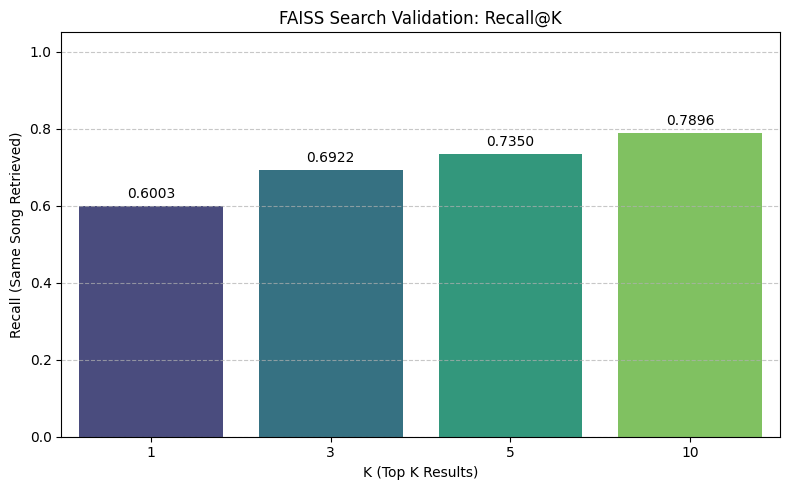

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create a bar plot for Recall@K
plt.figure(figsize=(8, 5))
sns.barplot(x='K', y='Recall', data=recall_df, palette='viridis')

# Add labels and title
plt.title('FAISS Search Validation: Recall@K')
plt.xlabel('K (Top K Results)')
plt.ylabel('Recall (Same Song Retrieved)')
plt.ylim(0, 1.05)  # Recall ranges from 0 to 1

# Add text annotations on top of the bars
for index, row in recall_df.iterrows():
    plt.text(index, row.Recall + 0.02, f"{row.Recall:.4f}", color='black', ha="center")

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the plot to Google Drive
RECALL_PLOT_PATH = os.path.join(DRIVE_BASE, "results", "recall_at_k_plot.png")
plt.savefig(RECALL_PLOT_PATH, dpi=150)
print(f"Plot saved → {RECALL_PLOT_PATH}")

plt.show()

## Section 6 — Create Chunks for Testing Data
Convert MIDI files from `7TestingSamples/MidiOutputs` to `.wav` files using FluidSynth, resample to 24kHz, and split into 7-second chunks.

In [ ]:
!apt-get update -qq
!apt-get install -y fluidsynth fluid-soundfont-gm
!pip install -q soundfile librosa

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  at-spi2-core gsettings-desktop-schemas libatk-bridge2.0-0 libatk1.0-0
  libatk1.0-data libatspi2.0-0 libdouble-conversion3 libevdev2 libfluidsynth3
  libgtk-3-0 libgtk-3-bin libgtk-3-common libgudev-1.0-0 libinput-bin
  libinput10 libinstpatch-1.0-2 libmd4c0 libmtdev1 libqt5core5a libqt5dbus5
  libqt5gui5 libqt5network5 libqt5svg5 libqt5widgets5 librsvg2-common
  libwacom-bin libwacom-common libwacom9 libxcb-icccm4 libxcb-image0
  libxcb-keysyms1 libxcb-render-util0 libxcb-util1 libxcb-xinerama0
  libxcb-xinput0 libxcb-xkb1 libxcomposite1 libxkbcommon-x11-0 libxtst6 qsynth
  qt5-gtk-platformtheme qttranslations5-l10n session-migration
Suggested packag

In [ ]:
import os
import subprocess
import librosa
import soundfile as sf
from tqdm import tqdm

# Paths
TEST_MIDI_DIR = "/content/drive/MyDrive/AAI-590 Capstone/capstone_team_3/MidiDatasets/TestingSamples/MidiOutputs"
TEST_CHUNK_DIR = "/content/drive/MyDrive/AAI-590 Capstone/capstone_team_3/MidiDatasets/TestingSamples/TestChunks"
os.makedirs(TEST_CHUNK_DIR, exist_ok=True)

# Configuration
SOUNDFONT = "/usr/share/sounds/sf2/FluidR3_GM.sf2"
TARGET_SR = 24000
CHUNK_LENGTH_SEC = 7
CHUNK_SAMPLES = TARGET_SR * CHUNK_LENGTH_SEC

# Recursively find MIDI files
midi_files = []
for root, dirs, files in os.walk(TEST_MIDI_DIR):
    for f in files:
        if f.endswith(('.mid', '.midi')):
            midi_files.append(os.path.join(root, f))

print(f"Found {len(midi_files)} MIDI files to process.")

for midi_path in tqdm(midi_files, desc="Converting and chunking MIDI files"):
    base_name = os.path.splitext(os.path.basename(midi_path))[0]
    temp_wav_path = os.path.join(TEST_CHUNK_DIR, f"{base_name}_temp.wav")

    # 1. Synthesize MIDI to WAV using FluidSynth
    # -F specifies output file, -ni for non-interactive, -r for sample rate
    cmd = ["fluidsynth", "-ni", SOUNDFONT, midi_path, "-F", temp_wav_path, "-r", "44100"]
    result = subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

    if not os.path.exists(temp_wav_path):
        print(f"\nFailed to convert {base_name}")
        continue

    # 2. Load the synthesized audio and resample to 24kHz
    try:
        audio, _ = librosa.load(temp_wav_path, sr=TARGET_SR)
    except Exception as e:
        print(f"\nError loading {temp_wav_path}: {e}")
        if os.path.exists(temp_wav_path):
            os.remove(temp_wav_path)
        continue

    # 3. Create 7-second chunks
    num_chunks = len(audio) // CHUNK_SAMPLES
    song_out_dir = os.path.join(TEST_CHUNK_DIR, base_name)
    os.makedirs(song_out_dir, exist_ok=True)

    for i in range(num_chunks):
        start = i * CHUNK_SAMPLES
        end = start + CHUNK_SAMPLES
        chunk_audio = audio[start:end]

        chunk_filename = f"{base_name}_chunk_{i+1}.wav"
        chunk_path = os.path.join(song_out_dir, chunk_filename)

        # Save chunk as 16-bit PCM WAV
        sf.write(chunk_path, chunk_audio, TARGET_SR, subtype='PCM_16')

    # Clean up temporary WAV file
    if os.path.exists(temp_wav_path):
        os.remove(temp_wav_path)

print("\nDone processing testing MIDI files!")

Found 101 MIDI files to process.


Converting and chunking MIDI files: 100%|██████████| 101/101 [09:45<00:00,  5.80s/it]


Done processing testing MIDI files!


## Section 7 — Generate Embeddings for Testing Chunks
Extracts 768-dim embeddings for all the `.wav` chunks in the testing dataset using the fine-tuned MERT+LoRA model and saves them to `TestSampleEmbeddings.pkl`.

In [ ]:
import os
import re
import librosa
import torch
import pandas as pd
import numpy as np
from tqdm import tqdm
import torch.nn.functional as F

# Ensure the evaluation model is in eval mode
eval_model.eval()

test_embeddings_data = []

# Find all song directories in the test chunk path
test_songs = [d for d in os.listdir(TEST_CHUNK_DIR) if os.path.isdir(os.path.join(TEST_CHUNK_DIR, d))]

for song in tqdm(test_songs, desc="Processing Test Songs"):
    song_path = os.path.join(TEST_CHUNK_DIR, song)

    for f in os.listdir(song_path):
        if f.endswith('.wav'):
            # Extract base filename and chunk index using regex
            match = re.search(r'^(.*)_chunk_(\d+)\.wav$', f)
            if match:
                base_filename = match.group(1)
                chunk_idx = int(match.group(2))
            else:
                base_filename = f.replace('.wav', '')
                chunk_idx = -1

            file_path = os.path.join(song_path, f)

            # Load audio
            try:
                audio, _ = librosa.load(file_path, sr=SR)
            except Exception as e:
                print(f"Error loading {file_path}: {e}")
                continue

            # Process input (add batch dim)
            inputs = processor(audio, sampling_rate=SR, return_tensors="pt")
            inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

            # Forward pass to get embedding
            with torch.no_grad():
                outputs = eval_model(**inputs)
                # Mean pool across time dimension and L2 normalize
                emb = outputs.last_hidden_state.mean(dim=1)
                emb = F.normalize(emb, p=2, dim=1).cpu().numpy()[0]  # Shape: (768,)

            # Create row dictionary
            row = {
                "filename": base_filename,
                "chunk_index": chunk_idx,
                "original_wav": f
            }

            # Append the 768 embedding values as individual columns
            for i in range(768):
                row[f"emb_{i}"] = emb[i]

            test_embeddings_data.append(row)

# Create DataFrame
test_embeddings_df = pd.DataFrame(test_embeddings_data)

# Save to Pickle
TEST_OUT_PKL = os.path.join(DRIVE_BASE, "results", "TestSampleEmbeddings.pkl")
os.makedirs(os.path.dirname(TEST_OUT_PKL), exist_ok=True)
test_embeddings_df.to_pickle(TEST_OUT_PKL)

print(f"\nSuccessfully extracted embeddings for {len(test_embeddings_df)} test chunks.")
print(f"Saved DataFrame to: {TEST_OUT_PKL}")
display(test_embeddings_df.head())

Processing Test Songs: 100%|██████████| 101/101 [00:43<00:00,  2.33it/s]



Successfully extracted embeddings for 4116 test chunks.
Saved DataFrame to: /content/drive/MyDrive/AAI-590 Capstone/MERT_Finetune/results/TestSampleEmbeddings.pkl


,filename,chunk_index,original_wav,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,...,emb_758,emb_759,emb_760,emb_761,emb_762,emb_763,emb_764,emb_765,emb_766,emb_767
0,Aragon (Fantasia) Op.47 part 6,1,Aragon (Fantasia) Op.47 part 6_chunk_1.wav,-0.002086,-0.029629,0.025635,0.010346,-0.004052,0.019603,-0.024070,...,-0.007505,-0.015777,0.052013,0.028352,-0.041753,-0.022179,-0.025575,0.097028,-0.020070,0.055225
1,Aragon (Fantasia) Op.47 part 6,2,Aragon (Fantasia) Op.47 part 6_chunk_2.wav,-0.001320,0.015488,0.039678,0.017580,-0.011154,0.038522,-0.007086,...,0.020801,-0.032939,0.048401,0.042286,-0.046900,-0.007617,-0.000983,0.059055,-0.043045,0.029757
2,Aragon (Fantasia) Op.47 part 6,3,Aragon (Fantasia) Op.47 part 6_chunk_3.wav,0.001768,-0.008821,-0.016391,0.013950,0.031667,0.030477,-0.012609,...,-0.014020,0.007760,0.080718,0.001648,-0.036408,-0.029289,-0.022194,0.105602,-0.017333,0.023174
3,Aragon (Fantasia) Op.47 part 6,4,Aragon (Fantasia) Op.47 part 6_chunk_4.wav,0.001017,0.000502,-0.009382,0.025452,0.018667,0.018528,-0.025678,...,-0.001272,0.009910,0.073502,0.010299,-0.037750,-0.028023,-0.011450,0.122212,-0.010137,0.031756
4,Aragon (Fantasia) Op.47 part 6,5,Aragon (Fantasia) Op.47 part 6_chunk_5.wav,-0.000522,-0.006645,0.013555,0.011354,0.003247,0.015454,-0.019947,...,-0.028178,-0.005920,0.050818,0.032715,-0.034595,-0.030504,-0.026249,0.108213,-0.004679,0.021669


## Section 8 — FAISS Search for Testing Chunks
Loads the `TestSampleEmbeddings.pkl` and queries the FAISS index to find the top 10 closest matches from the database for each testing chunk. The output is a DataFrame formatted with the query file name and top 1-10 matches and similarity scores.

In [ ]:
import pandas as pd
import numpy as np
import os

# Load Test Embeddings
TEST_OUT_PKL = os.path.join(DRIVE_BASE, "results", "TestSampleEmbeddings.pkl")
print(f"Loading test embeddings from: {TEST_OUT_PKL}")
test_df = pd.read_pickle(TEST_OUT_PKL)

# Extract just the 768-dim embedding columns
emb_cols = [f"emb_{i}" for i in range(768)]
test_embs = np.ascontiguousarray(test_df[emb_cols].values.astype('float32'))

# Perform FAISS Search for Top 10
k = 10
print(f"Searching FAISS index for top {k} matches...")
D_test, I_test = index.search(test_embs, k)

# Build the Results DataFrame
search_results = []

for i in range(len(test_df)):
    query_filename = test_df.iloc[i]['original_wav']

    row_data = {"query_file": query_filename}

    for rank in range(k):
        match_idx = I_test[i][rank]
        score = D_test[i][rank]

        # Retrieve match details from the train_df (our FAISS database)
        match_filename = train_df.iloc[match_idx]['original_wav']

        row_data[f"top_{rank+1}_match"] = match_filename
        row_data[f"top_{rank+1}_score"] = round(float(score), 4)

    search_results.append(row_data)

matches_df = pd.DataFrame(search_results)

# Save the results to CSV
MATCHES_OUT_CSV = os.path.join(DRIVE_BASE, "results", "test_top10_matches.csv")
matches_df.to_csv(MATCHES_OUT_CSV, index=False)

print(f"\nSuccessfully found top 10 matches for {len(matches_df)} test chunks.")
print(f"Results saved to: {MATCHES_OUT_CSV}")
display(matches_df.head())

Loading test embeddings from: /content/drive/MyDrive/AAI-590 Capstone/MERT_Finetune/results/TestSampleEmbeddings.pkl
Searching FAISS index for top 10 matches...

Successfully found top 10 matches for 4116 test chunks.
Results saved to: /content/drive/MyDrive/AAI-590 Capstone/MERT_Finetune/results/test_top10_matches.csv


,query_file,top_1_match,top_1_score,top_2_match,top_2_score,top_3_match,top_3_score,top_4_match,top_4_score,top_5_match,...,top_6_match,top_6_score,top_7_match,top_7_score,top_8_match,top_8_score,top_9_match,top_9_score,top_10_match,top_10_score
0,Aragon (Fantasia) Op.47 part 6_chunk_1.wav,brahms_opus1_4_chunk_45.wav,0.1404,alb_se6_chunk_168.wav,0.1510,schum_abegg_chunk_281.wav,0.1530,brahms_opus1_4_chunk_46.wav,0.1552,mz_333_1_chunk_30.wav,...,alb_se6_chunk_155.wav,0.1581,mz_332_1_chunk_256.wav,0.1598,haydn_9_3_chunk_27.wav,0.1614,mz_332_1_chunk_163.wav,0.1642,schub_d960_4_chunk_229.wav,0.1663
1,Aragon (Fantasia) Op.47 part 6_chunk_2.wav,schubert_D850_3_chunk_88.wav,0.2796,alb_se6_chunk_13.wav,0.3130,beethoven_hammerklavier_3_chunk_303.wav,0.3183,liz_rhap15_chunk_109.wav,0.3216,schu_143_3_chunk_101.wav,...,mz_311_1_chunk_56.wav,0.3230,schubert_D850_2_chunk_61.wav,0.3272,beethoven_hammerklavier_3_chunk_20.wav,0.3322,ty_september_chunk_105.wav,0.3323,grieg_butterfly_chunk_19.wav,0.3341
2,Aragon (Fantasia) Op.47 part 6_chunk_3.wav,chpn-p1_chunk_18.wav,0.1441,ty_juli_chunk_13.wav,0.1519,ty_juli_chunk_15.wav,0.1544,chpn-p1_chunk_19.wav,0.1551,scn16_5_chunk_91.wav,...,schumm-1_chunk_29.wav,0.1575,brahms_opus1_4_chunk_52.wav,0.1577,mz_333_1_chunk_249.wav,0.1629,schubert_D935_3_chunk_33.wav,0.1637,schuim-1_chunk_187.wav,0.1652
3,Aragon (Fantasia) Op.47 part 6_chunk_4.wav,chpn-p1_chunk_18.wav,0.1241,chpn-p1_chunk_19.wav,0.1248,mz_333_1_chunk_249.wav,0.1305,scn16_5_chunk_10.wav,0.1348,schubert_D935_3_chunk_33.wav,...,bor_ps3_chunk_64.wav,0.1391,bor_ps3_chunk_22.wav,0.1421,deb_prel_chunk_91.wav,0.1422,schumm-1_chunk_29.wav,0.1442,ty_februar_chunk_118.wav,0.1461
4,Aragon (Fantasia) Op.47 part 6_chunk_5.wav,chpn-p23_chunk_28.wav,0.1195,schub_d960_4_chunk_235.wav,0.1207,schubert_D935_1_chunk_371.wav,0.1213,mz_332_1_chunk_279.wav,0.1249,schubert_D935_1_chunk_365.wav,...,scn16_2_chunk_52.wav,0.1278,haydn_9_2_chunk_20.wav,0.1286,schubert_D935_3_chunk_233.wav,0.1297,mz_332_1_chunk_278.wav,0.1302,mz_332_1_chunk_185.wav,0.1302


In [ ]:
import pandas as pd
import os

# Convert the existing L2 distances (D_test) to Cosine Similarity
# Formula for L2-normalized embeddings: Cosine Similarity = 1 - (L2_distance / 2)
k = 10
similarity_results = []

print("Calculating Cosine Similarities...")
for i in range(len(test_df)):
    query_filename = test_df.iloc[i]['original_wav']
    row_data = {"query_file": query_filename}

    for rank in range(k):
        match_idx = I_test[i][rank]
        l2_dist = D_test[i][rank]

        cosine_sim = 1 - (l2_dist / 2)
        match_filename = train_df.iloc[match_idx]['original_wav']

        row_data[f"top_{rank+1}_match"] = match_filename
        row_data[f"top_{rank+1}_similarity"] = round(float(cosine_sim), 4)

    similarity_results.append(row_data)

sim_matches_df = pd.DataFrame(similarity_results)

# Save the results to a new CSV
SIM_OUT_CSV = os.path.join(DRIVE_BASE, "results", "test_top10_similarity.csv")
sim_matches_df.to_csv(SIM_OUT_CSV, index=False)

print(f"\nSuccessfully computed Cosine Similarities for {len(sim_matches_df)} test chunks.")
print(f"Results saved to: {SIM_OUT_CSV}")
display(sim_matches_df.head())


Calculating Cosine Similarities...

Successfully computed Cosine Similarities for 4116 test chunks.
Results saved to: /content/drive/MyDrive/AAI-590 Capstone/MERT_Finetune/results/test_top10_similarity.csv


,query_file,top_1_match,top_1_similarity,top_2_match,top_2_similarity,top_3_match,top_3_similarity,top_4_match,top_4_similarity,top_5_match,...,top_6_match,top_6_similarity,top_7_match,top_7_similarity,top_8_match,top_8_similarity,top_9_match,top_9_similarity,top_10_match,top_10_similarity
0,Aragon (Fantasia) Op.47 part 6_chunk_1.wav,brahms_opus1_4_chunk_45.wav,0.9298,alb_se6_chunk_168.wav,0.9245,schum_abegg_chunk_281.wav,0.9235,brahms_opus1_4_chunk_46.wav,0.9224,mz_333_1_chunk_30.wav,...,alb_se6_chunk_155.wav,0.9210,mz_332_1_chunk_256.wav,0.9201,haydn_9_3_chunk_27.wav,0.9193,mz_332_1_chunk_163.wav,0.9179,schub_d960_4_chunk_229.wav,0.9169
1,Aragon (Fantasia) Op.47 part 6_chunk_2.wav,schubert_D850_3_chunk_88.wav,0.8602,alb_se6_chunk_13.wav,0.8435,beethoven_hammerklavier_3_chunk_303.wav,0.8409,liz_rhap15_chunk_109.wav,0.8392,schu_143_3_chunk_101.wav,...,mz_311_1_chunk_56.wav,0.8385,schubert_D850_2_chunk_61.wav,0.8364,beethoven_hammerklavier_3_chunk_20.wav,0.8339,ty_september_chunk_105.wav,0.8338,grieg_butterfly_chunk_19.wav,0.8330
2,Aragon (Fantasia) Op.47 part 6_chunk_3.wav,chpn-p1_chunk_18.wav,0.9280,ty_juli_chunk_13.wav,0.9240,ty_juli_chunk_15.wav,0.9228,chpn-p1_chunk_19.wav,0.9225,scn16_5_chunk_91.wav,...,schumm-1_chunk_29.wav,0.9212,brahms_opus1_4_chunk_52.wav,0.9212,mz_333_1_chunk_249.wav,0.9186,schubert_D935_3_chunk_33.wav,0.9182,schuim-1_chunk_187.wav,0.9174
3,Aragon (Fantasia) Op.47 part 6_chunk_4.wav,chpn-p1_chunk_18.wav,0.9380,chpn-p1_chunk_19.wav,0.9376,mz_333_1_chunk_249.wav,0.9347,scn16_5_chunk_10.wav,0.9326,schubert_D935_3_chunk_33.wav,...,bor_ps3_chunk_64.wav,0.9305,bor_ps3_chunk_22.wav,0.9289,deb_prel_chunk_91.wav,0.9289,schumm-1_chunk_29.wav,0.9279,ty_februar_chunk_118.wav,0.9269
4,Aragon (Fantasia) Op.47 part 6_chunk_5.wav,chpn-p23_chunk_28.wav,0.9403,schub_d960_4_chunk_235.wav,0.9396,schubert_D935_1_chunk_371.wav,0.9393,mz_332_1_chunk_279.wav,0.9376,schubert_D935_1_chunk_365.wav,...,scn16_2_chunk_52.wav,0.9361,haydn_9_2_chunk_20.wav,0.9357,schubert_D935_3_chunk_233.wav,0.9351,mz_332_1_chunk_278.wav,0.9349,mz_332_1_chunk_185.wav,0.9349
